# Normalisation with CollateX

Remember the Gothenburg model of automated collation?  

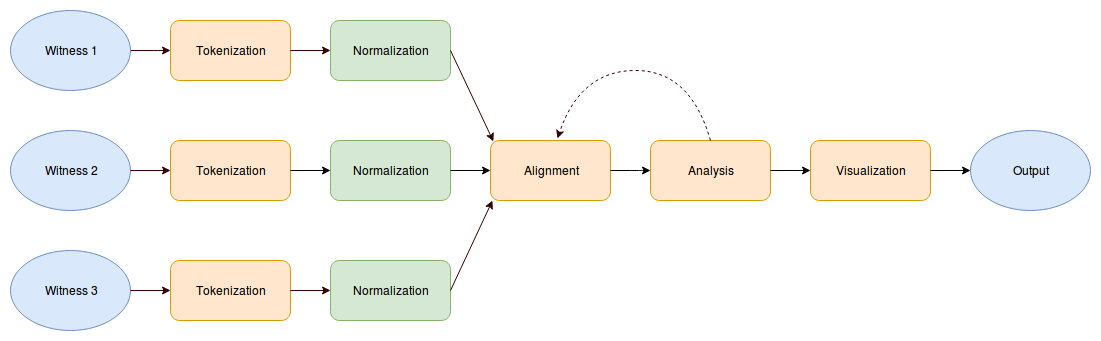

To recap: the model was [established](https://collatex.net/doc/) in 2011 by a group of developers and scholars who divided the collation process into separate components. These components form subsequent steps, with the output of one step providing the input of the next. By agreeing on this modular structure they could collaborate more easily, and finetune the development of individual components.  

The model also helps scholars to reflect on the collation of their own texts. Once you know which steps the software CollateX takes by default, you can estimate whether you may want to change some parameters to better handle the particularities of your material.



While the alignment step is for most CollateX users a black box, it is possible to adjust the alignment output if the default settings don't agree with your material or objective. You can change these settings for the tokenization and normalization steps.  

In what follows, you'll learn (step-by-step) how to play around with the tokenization and normalization settings. This is important because once you understand the influence of normalization on the collation helps you to design the best approach for your project.

If you're interested in the theoretical side of this, I can highly recommend [a recent article](http://www.digitalhumanities.org/dhq/vol/14/3/000489/000489.html) by David J. Birnbaum and Elena Spadini on the role of normalization in the collation process.

They state:

### "Normalization, in a nutshell, makes it possible to identify phenomena on multiple orthographic and linguistic levels and use them to create surrogates for the literal word tokens that then shape and interpret the results of collation, tacitly neutralizing and ignoring other distinctions that are present in the literal tokens."

So what are the default (built-in) settings of CollateX?  
- Input witnesses are **tokenized** on whitespace. This is the blank space punctuation in text, here represented as `_`;
- For each token, trailing whitespace is **normalized** and thus ignored by the aligner. 

This means, for example, that the tokens `cat` and `cat_` are considered as equal (= a match) by the alignment algortihm.   

So far, that's relatively simple. But you may want to consider additional normalization options, for example:
- **Lower and upper case**: e.g., `Cat` will be matched with `cat`;
- **Graphemes**: e.g, the Latin alphabet regular `s` will be matched with the long `ſ`;
- **Orthographic variation**: e.g., the British spelling `honour` will be matched with the American `honor`;
- **Morphological variation**: e.g., inflected forms of a verb, like `is` and `are` will be considered a match;
- **Lexical variation**: e.g., `journals` will be aligned with `magazines`.

The choices you make here depend on the purpose of your collation. The choices may even vary in different stages of the same project.



## Normalizing upper- and lower case

We'll start with an easy one: normalising cases. First, let's see the collation output without normalization:

In [ ]:
from collatex import*
collation_object = Collation()
collation_object.add_plain_witness('W1', 'I sit on the bank.')
collation_object.add_plain_witness('W2', 'You go to the Bank.')
result = collate(collation_object, output='html2', segmentation=False)
print(result)

As you can see, the tokens `Bank` in witness 1 and `bank` in witness 2 are *not* considered matches. Let's say we'd like the alignment algorithm to ignore the cases of the tokens, so that `bank` will be matched with `Bank`:

In [ ]:
from collatex import *
import json
norm_collation_obj = Collation()
json_input = """{
"witnesses": [
{"id": "W1", "tokens": [
{"t": "The", "n": "the"},
{"t": "Bank", "n": "bank"},
{"t":"of", "n": "of"}, 
{"t":"England", "n": "england"},
{"t":"&", "n":"and"},
{"t":"the", "n": "the"},
{"t":"Indian", "n": "indian"},
{"t":"Empire", "n": "empire"}
]
},
{"id": "W2", "tokens": [
{"t": "the", "n": "the"},
{"t": "bank", "n": "bank"},
{"t":"of", "n": "of"}, 
{"t":"england", "n": "england"},
{"t":"and", "n":"and"},
{"t":"the", "n": "the"},
{"t":"indian", "n": "indian"},
{"t":"empire", "n": "empire"}
]
}
]
}"""
collate(json.loads(json_input), segmentation=False, output='html2')

Obviously, this manual entry of shadow tokens in JSON is time-consuming, but luckily you can automate this. I won't go into detail here. If you'd like to learn more about it, go check out [this notebook](https://github.com/automaticCollationLausanne2020/Materials/blob/master/session7/Session07b_Normalization.ipynb) from the Automated Collation Lausanne workshop 2020!